# Steelmaking capacity: no_cap vs. capped, by period

In [36]:
from pathlib import Path

import pandas as pd

BASE_DIR = Path('.')
PERIODS = [1, 2, 3, 4]
SCENARIOS = {'no_cap': 'no_cap_results_period_{}', 'capped': 'results_period_{}'}


def load_capacity(scenario, period):
    folder = BASE_DIR / SCENARIOS[scenario].format(period)
    df = pd.read_csv(folder / 'capacity.csv')
    df = df[df['commodity'] == 'CrudeSteel']
    df = df[~df['resource_id'].str.contains('transport')]
    return df.set_index('resource_id')['capacity']


tables = {}
for period in PERIODS:
    no_cap = load_capacity('no_cap', period)
    capped = load_capacity('capped', period)
    df = pd.DataFrame({'no_cap': no_cap, 'capped': capped})
    df['diff'] = df['capped'] - df['no_cap']
    tables[period] = df

FileNotFoundError: [Errno 2] No such file or directory: 'no_cap_results_period_1/capacity.csv'

## Period 1

In [ ]:
tables[1]

,no_cap,capped,diff
resource_id,,,
Region1Beijing_bfbof,6369.976531,6369.980933,0.004402
Region2Tianjin_bfbof,1557.976990,1557.975119,-0.001870
Region3Hebei_bfbof,23966.792810,23966.972464,0.179653
Region4Shanxi_bfbof,6699.995230,6699.999727,0.004497
Region5Innermongolia_bfbof,3134.996214,3134.982690,-0.013524
...,...,...,...
Region27Shaanxi_scrapeaf56,0.012013,0.029966,0.017953
Region28Gansu_scrapeaf56,0.001904,0.002828,0.000924
Region29Qinghai_scrapeaf56,0.000379,0.000290,-0.000090


## Period 2

In [ ]:
tables[2]

,no_cap,capped,diff
resource_id,,,
Region1Beijing_bfbof,6327.000892,6369.880373,42.879481
Region2Tianjin_bfbof,0.314459,0.555949,0.241490
Region3Hebei_bfbof,23966.647670,23966.957757,0.310087
Region4Shanxi_bfbof,6699.994902,6699.996633,0.001730
Region5Innermongolia_bfbof,3134.996362,3134.954160,-0.042201
...,...,...,...
Region27Shaanxi_scrapeaf56,0.001041,0.001154,0.000113
Region28Gansu_scrapeaf56,0.000879,0.000903,0.000024
Region29Qinghai_scrapeaf56,0.000412,0.000350,-0.000062


## Period 3

In [ ]:
tables[3]

,no_cap,capped,diff
resource_id,,,
Region1Beijing_bfbof,3522.909125,3534.837727,11.928602
Region2Tianjin_bfbof,0.009559,0.010480,0.000921
Region3Hebei_bfbof,16469.893048,18226.736062,1756.843015
Region4Shanxi_bfbof,6699.846334,6699.955209,0.108875
Region5Innermongolia_bfbof,3134.280383,3133.655338,-0.625045
...,...,...,...
Region27Shaanxi_scrapeaf56,0.001054,0.001039,-0.000016
Region28Gansu_scrapeaf56,0.000922,0.000903,-0.000018
Region29Qinghai_scrapeaf56,0.000414,0.000366,-0.000048


## Period 4

In [ ]:
tables[4]

,no_cap,capped,diff
resource_id,,,
Region1Beijing_bfbof,0.000586,0.000495,-0.000091
Region2Tianjin_bfbof,0.000464,0.000389,-0.000074
Region3Hebei_bfbof,0.000637,0.000541,-0.000096
Region4Shanxi_bfbof,0.000632,0.000531,-0.000101
Region5Innermongolia_bfbof,0.000652,0.000528,-0.000124
...,...,...,...
Region27Shaanxi_scrapeaf56,0.001006,0.000813,-0.000192
Region28Gansu_scrapeaf56,0.000863,0.000644,-0.000219
Region29Qinghai_scrapeaf56,0.000407,0.000347,-0.000060


## Steelmaking capacity by province: no_cap vs. capped

Province-level pie maps of total installed `capacity` (existing + new − retired) for the five steelmaking technologies (`bfbof`, `bfbofccs`, `scrapeaf56`, `scrapeaf100`, `drieaf`), one 4-period row per scenario.

In [ ]:
import math
import re

import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Circle


def plot_province_pies(
    gdf,
    data_df,
    province_col="NAME_1",
    categories=None,
    colors=None,
    pie_scale=1.0,
    figsize=(14, 10),
    dpi=150,
    title="",
    legend_sizes=None,
    capacity_unit="MW",
    max_total_override=None,
    ax=None,
):
    if categories is None:
        categories = list(data_df.columns)

    if colors is None:
        cmap = plt.cm.tab20
        colors = {cat: cmap(i) for i, cat in enumerate(categories)}

    gdf_proj = gdf.to_crs(epsg=3857)
    gdf_proj = gdf_proj.merge(data_df, left_on=province_col, right_index=True, how="left")
    gdf_proj[categories] = gdf_proj[categories].fillna(0)

    gdf_proj["centroid"] = gdf_proj.geometry.centroid
    gdf_proj["cx"] = gdf_proj.centroid.x
    gdf_proj["cy"] = gdf_proj.centroid.y

    gdf_proj["total_value"] = gdf_proj[categories].sum(axis=1)
    max_total = max_total_override if max_total_override is not None else (gdf_proj["total_value"].max() or 1)
    gdf_proj["radius"] = (gdf_proj["total_value"] / max_total) * pie_scale * 80_000

    _own_fig = ax is None
    if _own_fig:
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.set_axis_off()

    for _, row in gdf_proj.iterrows():
        cx, cy, r = row["cx"], row["cy"], row["radius"]
        vals = row[categories].values.astype(float)
        total = vals.sum()
        if total == 0:
            continue
        angles = np.cumsum(vals) / total * 360
        prev_angle = 0
        for cat, angle in zip(categories, angles):
            wedge = Wedge(
                center=(cx, cy), r=r,
                theta1=prev_angle, theta2=angle,
                facecolor=colors[cat], edgecolor="none",
                alpha=1.0, zorder=1000
            )
            ax.add_patch(wedge)
            prev_angle = angle

    gdf_proj.plot(ax=ax, color="#F4F4F4", edgecolor="none", zorder=0)
    gdf_proj.boundary.plot(ax=ax, linewidth=0.3, color="black", zorder=1)

    if legend_sizes is not None and len(legend_sizes) > 0:
        legend_radii = [(s / max_total) * pie_scale * 80_000 for s in legend_sizes]
        sizes_and_radii = sorted(zip(legend_sizes, legend_radii))
        max_r = max(legend_radii)

        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        plot_width = xlim[1] - xlim[0]
        pad_x = plot_width * 0.02
        gap = max_r * 0.5

        strip_height = gap + sum(r * 2 + gap for _, r in sizes_and_radii)
        ax.set_ylim(ylim[0] - strip_height, ylim[1])
        ylim = ax.get_ylim()

        legend_cx = xlim[0] + pad_x + max_r
        y = ylim[0] + gap
        for size, radius in sizes_and_radii:
            cy_legend = y + radius
            circle = Circle(
                (legend_cx, cy_legend), radius,
                facecolor="white", edgecolor="#555555",
                linewidth=1.2, zorder=2000
            )
            ax.add_patch(circle)
            ax.text(
                legend_cx + max_r + pad_x * 0.6, cy_legend,
                f"{size:,.0f} {capacity_unit}",
                va="center", ha="left", fontsize=9, zorder=2001
            )
            y += radius * 2 + gap

    if _own_fig:
        ax.set_title(title, fontsize=18)
        plt.tight_layout()
        plt.show()
        plt.close()

    return ax


def _nice_round_up(x):
    if x <= 0:
        return 1
    mag = 10 ** math.floor(math.log10(x))
    for f in [1, 2, 5, 10]:
        candidate = f * mag
        if candidate >= x:
            return int(candidate)
    return int(x)


def _nice_legend_sizes(max_val):
    top = _nice_round_up(max_val)
    mid = _nice_round_up(max_val * 0.5)
    small = _nice_round_up(max_val * 0.25)
    return sorted(set([small, mid, top]))

In [ ]:
gdf = gpd.read_file("../results/gadm36_CHN_1.json")
rename_map = {
    "Nei Mongol": "Innermongolia",
    "Xizang": "Tibet",
    "Ningxia Hui": "Ningxia",
    "Xinjiang Uygur": "Xinjiang",
}
gdf["NAME_1"] = gdf["NAME_1"].replace(rename_map)

In [ ]:
STEEL_TECHS = {
    "bfbof": "BF-BOF",
    "bfbofccs": "BF-BOF-CCS",
    "scrapeaf56": "Scrap EAF 56%",
    "scrapeaf100": "Scrap EAF 100%",
    "drieaf": "DRI-EAF",
}
STEEL_COLORS = {
    "BF-BOF": "#1f77b4",
    "BF-BOF-CCS": "#0ee3ff",
    "Scrap EAF 56%": "#38a938",
    "Scrap EAF 100%": "#6acaa2",
    "DRI-EAF": "#9467bd",
}
ANNUAL_SCALE = 8760 / 1e6  # Tonnes/hour -> MT/year
ROW_RE = re.compile(r"^Region\d+([A-Za-z]+)_(" + "|".join(STEEL_TECHS) + r")$")


def load_capacity_by_province(scenario, period):
    folder = BASE_DIR / SCENARIOS[scenario].format(period)
    df = pd.read_csv(folder / "capacity.csv")
    df = df[df["commodity"] == "CrudeSteel"].copy()
    extracted = df["resource_id"].str.extract(ROW_RE)
    df["province"] = extracted[0]
    df["technology"] = extracted[1].map(STEEL_TECHS)
    df = df.dropna(subset=["province", "technology"])
    pivot = (
        df.groupby(["province", "technology"])["capacity"].sum()
        .unstack("technology")
        .reindex(columns=list(STEEL_TECHS.values()))
        .fillna(0)
    )
    return pivot * ANNUAL_SCALE


province_data = {
    scenario: {period: load_capacity_by_province(scenario, period) for period in PERIODS}
    for scenario in SCENARIOS
}

global_max = max(
    df.sum(axis=1).max()
    for periods in province_data.values()
    for df in periods.values()
)
legend_sizes = _nice_legend_sizes(global_max)
print(f"Global max capacity (single province, single period): {global_max:,.1f} MT/year")
print(f"Legend sizes: {legend_sizes}")

# Sanity check: national totals by scenario/period, MT/year
national = pd.DataFrame({
    (scenario, period): province_data[scenario][period].sum()
    for scenario in SCENARIOS for period in PERIODS
}).T
national.index.names = ["scenario", "period"]
national["total"] = national.sum(axis=1)
national.round(1)

Global max capacity (single province, single period): 236.5 MT/year
Legend sizes: [100, 200, 500]


technology       BF-BOF  BF-BOF-CCS  Scrap EAF 56%  Scrap EAF 100%  DRI-EAF  \
scenario period                                                               
no_cap   1        956.0         0.0           12.0             0.0      0.0   
         2        801.0         0.0            0.0             0.0     17.0   
         3        702.8         0.0            0.0             0.0     36.1   
         4          0.0         0.0            0.0            50.9    593.7   
capped   1        948.0         0.0           20.0             0.0      0.0   
         2        807.4         0.0            0.0             0.0     10.6   
         3        718.4         0.0            0.0             0.0     20.5   
         4          0.0         0.0            0.0            50.9    593.7   

technology       total  
scenario period         
no_cap   1       968.0  
         2       818.0  
         3       738.9  
         4       644.6  
capped   1       968.0  
         2       818.0  
         3       738.9  
         4       644.6

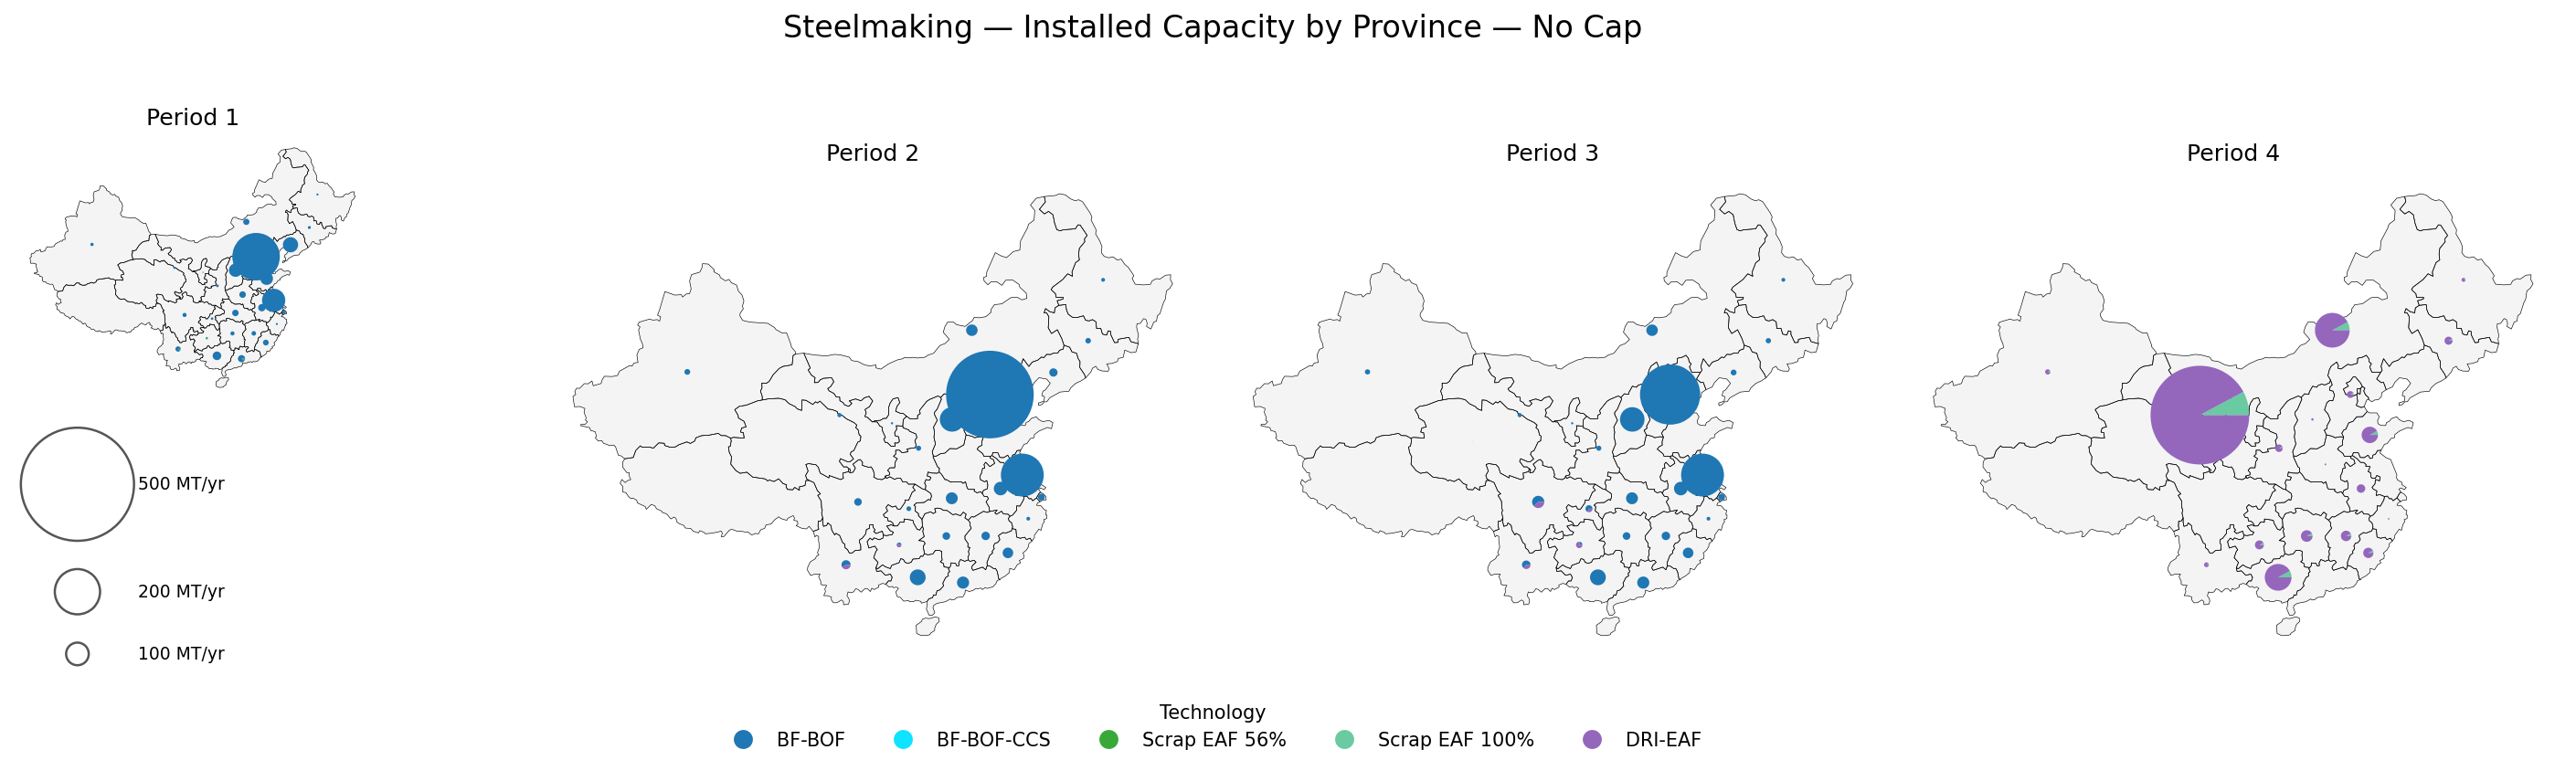

In [ ]:
def plot_scenario_grid(scenario_key, scenario_label):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5.5), dpi=150)
    for i, period in enumerate(PERIODS):
        ax = axes[i]
        plot_province_pies(
            gdf, province_data[scenario_key][period],
            colors=STEEL_COLORS,
            pie_scale=7,
            ax=ax,
            legend_sizes=legend_sizes if i == 0 else None,
            capacity_unit="MT/yr",
            max_total_override=global_max,
        )
        ax.set_title(f"Period {period}", fontsize=12)

    handles = [
        plt.Line2D([0], [0], marker="o", linestyle="", markerfacecolor=c,
                   markeredgecolor="none", markersize=10, label=tech)
        for tech, c in STEEL_COLORS.items()
    ]
    fig.legend(
        handles=handles, loc="lower center", ncol=len(STEEL_COLORS),
        frameon=False, bbox_to_anchor=(0.5, -0.02), title="Technology"
    )

    fig.suptitle(
        f"Steelmaking — Installed Capacity by Province — {scenario_label}",
        fontsize=16
    )
    fig.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()
    plt.close(fig)


plot_scenario_grid("no_cap", "No Cap")

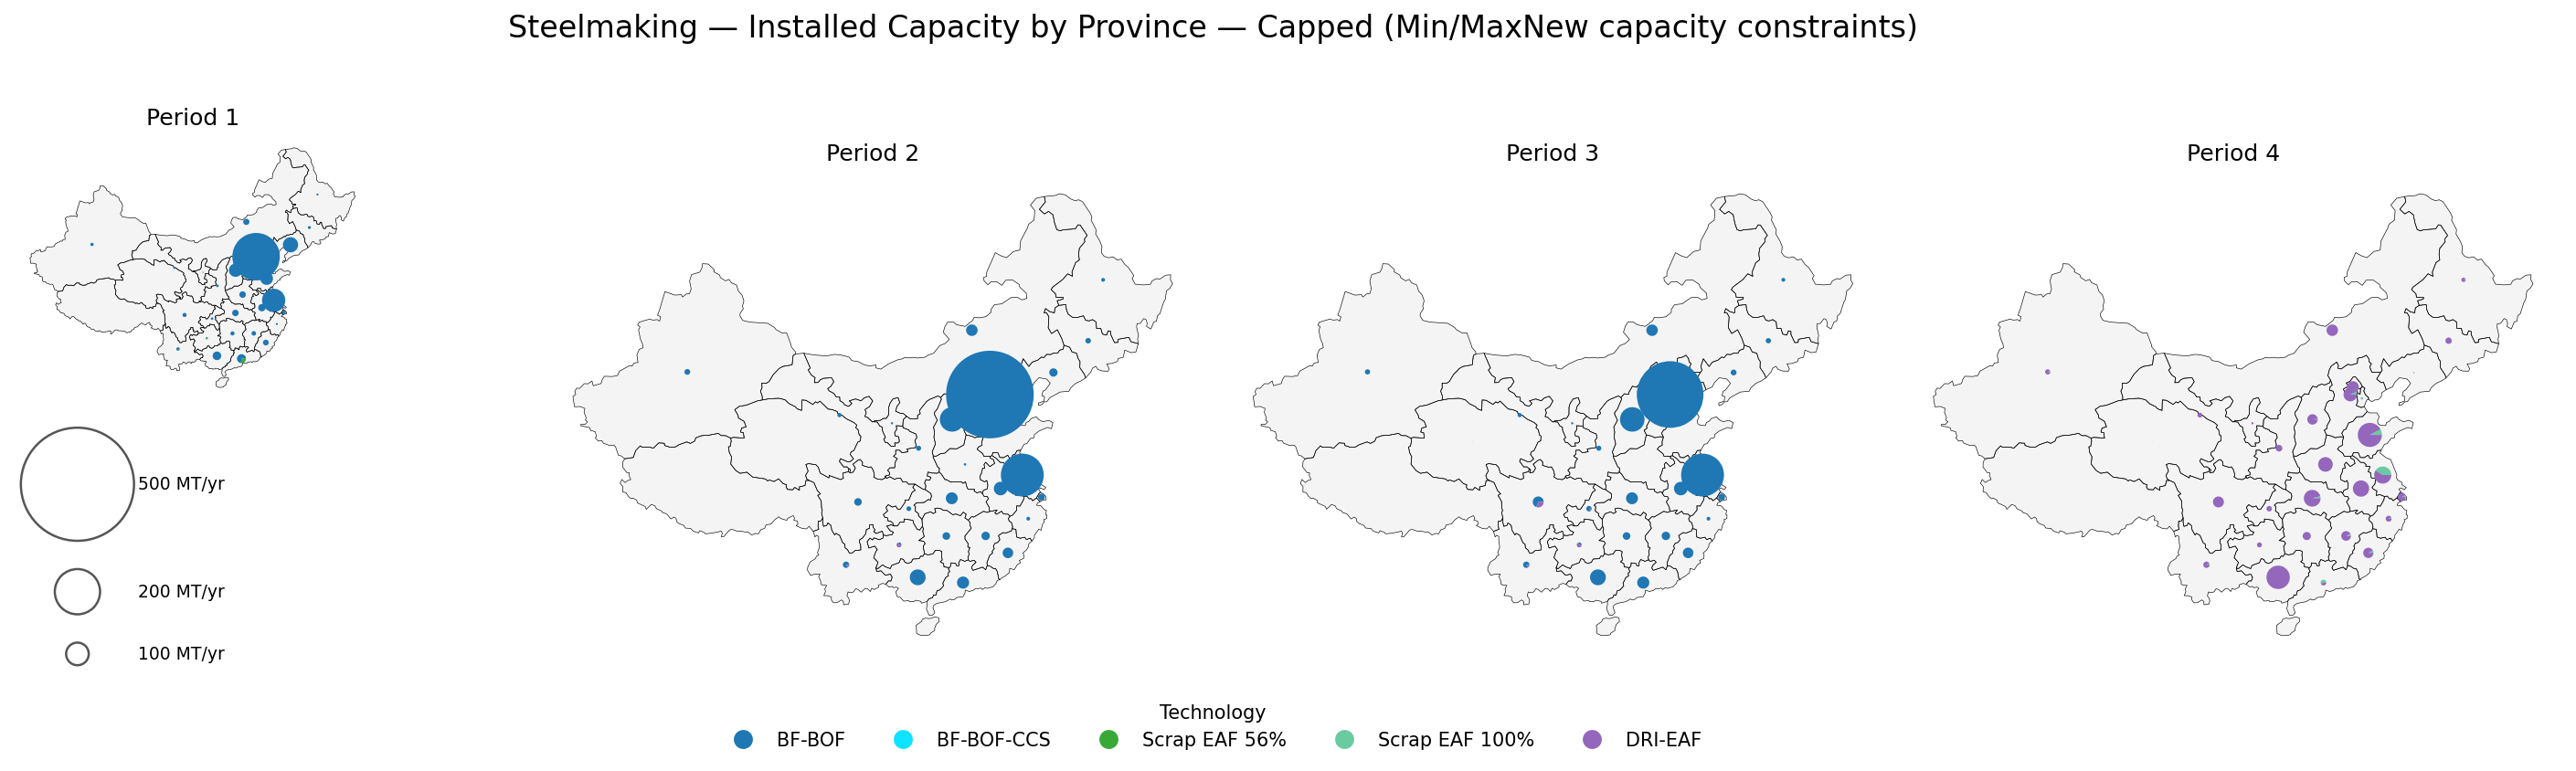

In [ ]:
plot_scenario_grid("capped", "Capped (Min/MaxNew capacity constraints)")